In [1]:
#1: Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from collections import Counter

In [2]:
#2: Loading Dataset and Model Results 

df = pd.read_csv("eda_dataset.csv")

results = pd.read_csv("model_evaluation_results.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (53379, 10)


,platform,review,rating,date,source,review_length,Original_reviws,tokens,clean_review,sentiment
0,Cars24,the pdi tool turned my automobile acquiring jo...,5,2026-07-16,Google Play,111,The PDI tool turned my automobile acquiring jo...,"['pdi', 'tool', 'turned', 'automobile', 'acqui...",pdi tool turned automobile acquiring journey f...,Positive
1,Cars24,getting to buy a pre owned automobile via this...,5,2026-07-16,Google Play,107,Getting to buy a pre owned automobile via this...,"['getting', 'buy', 'pre', 'owned', 'automobile...",getting buy pre owned automobile via applicati...,Positive
2,Cars24,getting to buy a vehicle turned out far simple...,5,2026-07-16,Google Play,221,Getting to buy a vehicle turned out far simple...,"['getting', 'buy', 'vehicle', 'turned', 'far',...",getting buy vehicle turned far simpler utilizi...,Positive
3,Cars24,the pdi report explained every detail in a cle...,5,2026-07-16,Google Play,68,The PDI report explained every detail in a cle...,"['pdi', 'report', 'explained', 'every', 'detai...",pdi report explained every detail clear simple...,Positive
4,Cars24,i enjoyed a fluid path because the buy journey...,5,2026-07-16,Google Play,89,I enjoyed a fluid path because the buy journey...,"['enjoyed', 'fluid', 'path', 'buy', 'journey',...",enjoyed fluid path buy journey felt safe strai...,Positive


In [3]:
#3: Check Available Columns
print(df.columns.tolist())
df.head()

['platform', 'review', 'rating', 'date', 'source', 'review_length', 'Original_reviws', 'tokens', 'clean_review', 'sentiment']


,platform,review,rating,date,source,review_length,Original_reviws,tokens,clean_review,sentiment
0,Cars24,the pdi tool turned my automobile acquiring jo...,5,2026-07-16,Google Play,111,The PDI tool turned my automobile acquiring jo...,"['pdi', 'tool', 'turned', 'automobile', 'acqui...",pdi tool turned automobile acquiring journey f...,Positive
1,Cars24,getting to buy a pre owned automobile via this...,5,2026-07-16,Google Play,107,Getting to buy a pre owned automobile via this...,"['getting', 'buy', 'pre', 'owned', 'automobile...",getting buy pre owned automobile via applicati...,Positive
2,Cars24,getting to buy a vehicle turned out far simple...,5,2026-07-16,Google Play,221,Getting to buy a vehicle turned out far simple...,"['getting', 'buy', 'vehicle', 'turned', 'far',...",getting buy vehicle turned far simpler utilizi...,Positive
3,Cars24,the pdi report explained every detail in a cle...,5,2026-07-16,Google Play,68,The PDI report explained every detail in a cle...,"['pdi', 'report', 'explained', 'every', 'detai...",pdi report explained every detail clear simple...,Positive
4,Cars24,i enjoyed a fluid path because the buy journey...,5,2026-07-16,Google Play,89,I enjoyed a fluid path because the buy journey...,"['enjoyed', 'fluid', 'path', 'buy', 'journey',...",enjoyed fluid path buy journey felt safe strai...,Positive


In [7]:
results = results.loc[:, ~results.columns.str.contains('^Unnamed')]

In [8]:
#4: Final Model Comparison
print("FINAL MODEL COMPARISON")
print("=" * 50)

results.sort_values(by="Accuracy", ascending=False)
results

FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,F1 Score
0,0.908486,0.892031,0.908486,0.899103
1,0.918415,0.904241,0.918415,0.908644
2,0.915886,0.900777,0.915886,0.906144
3,0.905676,0.889775,0.905676,0.896707


In [12]:
# #5: Identify the Best Model Automatically

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

best_model_name = results.index[0]

best_accuracy = results.iloc[0]["Accuracy"]

best_f1 = results.iloc[0]["F1 Score"]

print("Best Performing Model:", best_model_name)

print(
    "Best Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)

print(
    "Best F1 Score:",
    round(best_f1 * 100, 2),
    "%"
)

Best Performing Model: 1
Best Accuracy: 91.84 %
Best F1 Score: 90.86 %


platform
Cars24    45074
Spinny     8305
Name: count, dtype: int64


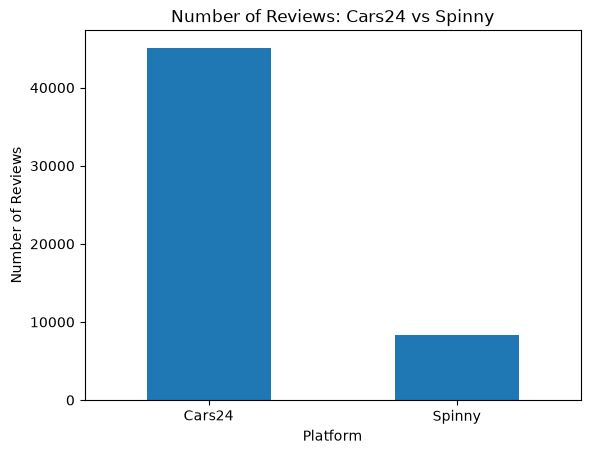

In [13]:
#6: Platform wise review count
platform_counts = df["platform"].value_counts()

print(platform_counts)

platform_counts.plot(kind="bar")

plt.title("Number of Reviews: Cars24 vs Spinny")
plt.xlabel("Platform")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

platform
Cars24    3.392133
Spinny    2.560867
Name: rating, dtype: float64


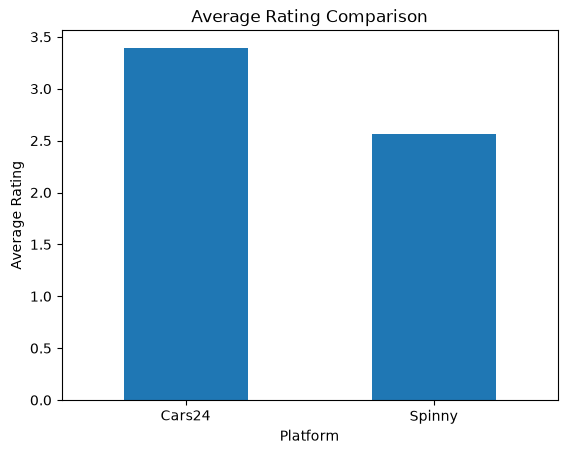

In [14]:
#7: Average Rating Count
average_ratings = df.groupby("platform")["rating"].mean()

print(average_ratings)

average_ratings.plot(kind="bar")

plt.title("Average Rating Comparison")
plt.xlabel("Platform")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)

plt.show()

sentiment  Negative  Neutral  Positive
platform                              
Cars24        17157      954     26963
Spinny         4943      191      3171


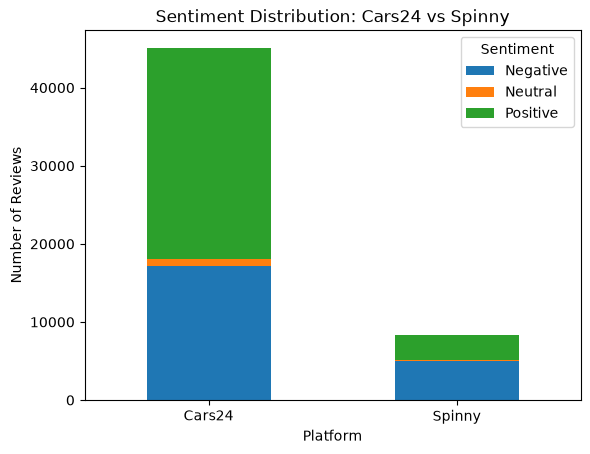

In [15]:
#8: Sentiment Distribution by Platform
sentiment_platform = pd.crosstab(
    df["platform"],
    df["sentiment"]
)

print(sentiment_platform)

sentiment_platform.plot(
    kind="bar",
    stacked=True
)

plt.title("Sentiment Distribution: Cars24 vs Spinny")
plt.xlabel("Platform")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.legend(title="Sentiment")

plt.show()

In [16]:
#9: Sentiment Percentage Comparision
sentiment_percentage = pd.crosstab(
    df["platform"],
    df["sentiment"],
    normalize="index"
) * 100

sentiment_percentage = sentiment_percentage.round(2)

sentiment_percentage

sentiment,Negative,Neutral,Positive
platform,,,
Cars24,38.06,2.12,59.82
Spinny,59.52,2.30,38.18


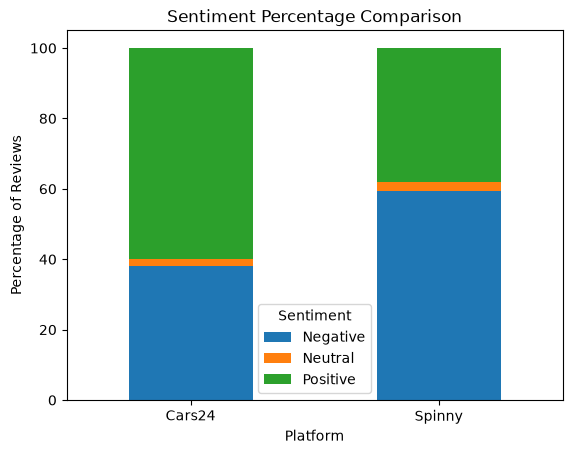

In [17]:
sentiment_percentage.plot(
    kind="bar",
    stacked=True
)

plt.title("Sentiment Percentage Comparison")
plt.xlabel("Platform")
plt.ylabel("Percentage of Reviews")

plt.xticks(rotation=0)

plt.legend(title="Sentiment")

plt.show()

In [19]:
#10: Rating Dashboard By platform
rating_platform = pd.crosstab(
    df["platform"],
    df["rating"]
)

rating_platform

rating,1,2,3,4,5
platform,,,,,
Cars24,16081,1076,954,3013,23950
Spinny,4683,260,191,363,2808


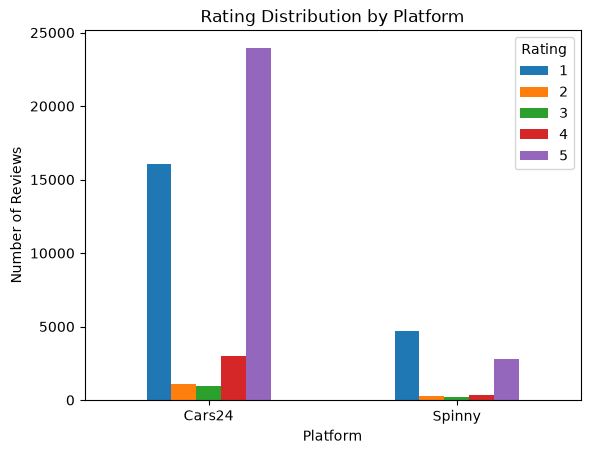

In [20]:
rating_platform.plot(
    kind="bar"
)

plt.title("Rating Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.legend(title="Rating")

plt.show()

In [21]:
#11: Source-Wise Comparison 
source_platform = pd.crosstab(
    df["platform"],
    df["source"]
)

source_platform

source,Google Play,Trustpilot
platform,,
Cars24,45046,28
Spinny,8250,55


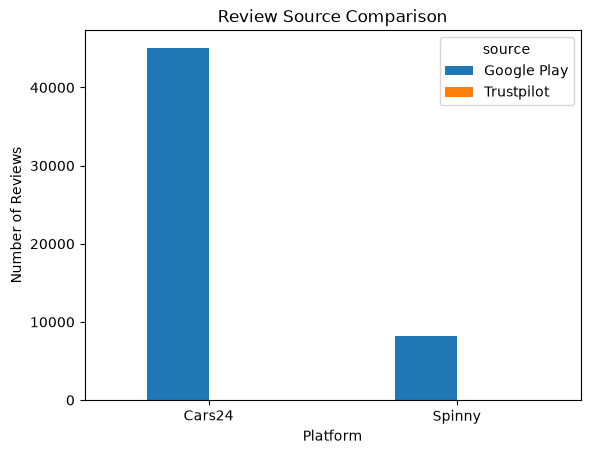

In [22]:
source_platform.plot(
    kind="bar"
)

plt.title("Review Source Comparison")
plt.xlabel("Platform")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

In [24]:
#12: Most Common Words in Reviews by Platform
def get_common_words(data, column="clean_review", top_n=15):

    text = " ".join(
        data[column]
        .dropna()
        .astype(str)
    )

    words = text.split()

    return Counter(words).most_common(top_n)

In [25]:
#Cars24
cars24_words = get_common_words(
    df[df["platform"] == "Cars24"]
)

print("Cars24 Most Common Words:")

for word, count in cars24_words:
    print(word, ":", count)

Cars24 Most Common Words:
car : 42297
app : 16450
good : 9941
price : 9340
service : 8106
experience : 7077
best : 6655
sell : 6083
time : 4517
buy : 4397
selling : 4069
process : 3980
inspection : 3793
customer : 3782
worst : 3386


In [26]:
#Spinny
spinny_words = get_common_words(
    df[df["platform"] == "Spinny"]
)

print("\nSpinny Most Common Words:")

for word, count in spinny_words:
    print(word, ":", count)


Spinny Most Common Words:
car : 6691
spinny : 4221
service : 1959
price : 1923
experience : 1716
app : 1708
good : 1527
time : 1236
customer : 1170
worst : 1060
buy : 988
sell : 972
call : 859
team : 830
day : 775


In [27]:
#13: Comparing Positive and Negative words
positive_df = df[df["sentiment"] == "Positive"]

negative_df = df[df["sentiment"] == "Negative"]

print("Positive Words:")
print(get_common_words(positive_df, top_n=20))

print("\nNegative Words:")
print(get_common_words(negative_df, top_n=20))


Positive Words:
[('car', 25138), ('app', 11369), ('good', 9731), ('best', 6678), ('service', 5319), ('experience', 5291), ('price', 4601), ('sell', 3941), ('process', 3833), ('great', 3239), ('selling', 3160), ('buy', 2842), ('easy', 2794), ('nice', 2750), ('used', 2712), ('staff', 2354), ('buying', 2283), ('really', 2090), ('team', 2017), ('application', 1876)]

Negative Words:
[('car', 23323), ('price', 6493), ('app', 6486), ('service', 4637), ('worst', 4422), ('time', 4315), ('call', 3597), ('customer', 3441), ('experience', 3434), ('sell', 3067), ('spinny', 2851), ('inspection', 2756), ('bad', 2751), ('buy', 2490), ('even', 2250), ('one', 2159), ('day', 2122), ('hai', 2113), ('company', 2101), ('get', 1866)]


In [30]:
#14: Load The best model
best_model = joblib.load("best_sentiment_model.pkl")


c:\Users\gatti\OneDrive\Desktop\4th year project\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gatti\OneDrive\Desktop\4th year project\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [31]:
#15: Loading the vectorizer
tfidf = joblib.load("tfidf_vectorizer.pkl")

c:\Users\gatti\OneDrive\Desktop\4th year project\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gatti\OneDrive\Desktop\4th year project\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [38]:
import re
import string
import nltk
import contractions
import emoji

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gatti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gatti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gatti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gatti\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gatti\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [39]:
def preprocess_new_review(review):

    review = str(review)

    review = review.lower()

    review = re.sub(r"http\S+|www\S+", "", review)

    review = re.sub(r"<.*?>", "", review)

    review = re.sub(r"\S+@\S+", "", review)

    review = contractions.fix(review)

    review = emoji.replace_emoji(review, replace="")

    review = re.sub(r"\d+", "", review)

    review = review.translate(
        str.maketrans("", "", string.punctuation)
    )

    review = re.sub(r"\s+", " ", review).strip()

    tokens = word_tokenize(review)
    
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [40]:

def predict_sentiment(review):
    review_vector = tfidf.transform([review])
    prediction = best_model.predict(review_vector)[0]
    return prediction

In [43]:
#16: Creating a Final Sentiment Prediction Function
def predict_sentiment(review):

    clean_review = preprocess_new_review(review)

    review_vector = tfidf.transform([clean_review])

    prediction = best_model.predict(review_vector)[0]

    return prediction

In [44]:
review1 = "The car was in excellent condition and the delivery process was very smooth."

print("Review:", review1)
print("Prediction:", predict_sentiment(review1))

Review: The car was in excellent condition and the delivery process was very smooth.
Prediction: Positive


In [45]:
review2 = "The documentation process was extremely slow and customer support was not helpful."

print("Review:", review2)
print("Prediction:", predict_sentiment(review2))

Review: The documentation process was extremely slow and customer support was not helpful.
Prediction: Positive


In [46]:
review3 = "The overall experience was okay, but the delivery took longer than expected."

print("Review:", review3)
print("Prediction:", predict_sentiment(review3))

Review: The overall experience was okay, but the delivery took longer than expected.
Prediction: Positive


In [47]:
print(df["sentiment"].value_counts())

sentiment
Positive    30134
Negative    22100
Neutral      1145
Name: count, dtype: int64


In [48]:
print(
    df["sentiment"].value_counts(normalize=True) * 100
)

sentiment
Positive    56.452912
Negative    41.402049
Neutral      2.145038
Name: proportion, dtype: float64


In [49]:
print(results)

   Accuracy  Precision    Recall  F1 Score
1  0.918415   0.904241  0.918415  0.908644
2  0.915886   0.900777  0.915886  0.906144
0  0.908486   0.892031  0.908486  0.899103
3  0.905676   0.889775  0.905676  0.896707


In [50]:
print(df["sentiment"].value_counts())

sentiment
Positive    30134
Negative    22100
Neutral      1145
Name: count, dtype: int64


In [ ]:
# Prepare features and target
X = tfidf.transform(df['clean_review'])
y = df['sentiment']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

print(classification_report(
    y_test,
    y_pred
))

NameError: name 'X_test' is not defined